In [59]:
import pandas as pd
import spacy
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import dbscan
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import cosine_similarity

In [60]:
df = pd.read_csv("C:/Users/mickt/Downloads/archive(5)/sample-data.csv")

### Data check

In [5]:
df.head()

,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...
3,4,"Alpine guide pants - Skin in, climb ice, switc..."
4,5,"Alpine wind jkt - On high ridges, steep ice an..."


In [80]:
df.shape

(500, 3)

In [6]:
df.describe()

,id
count,500.000000
mean,250.500000
std,144.481833
min,1.000000
25%,125.750000
50%,250.500000
75%,375.250000
max,500.000000


In [61]:
df.isna().sum()

id             0
description    0
dtype: int64

#### Everything looks good data-wise.

### Vectorization and cosine similarity estimation

In [62]:
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df['description'])
similarity_matrix = cosine_similarity(tfidf_matrix)
distance_matrix = pairwise_distances(tfidf_matrix, metric='cosine')
print("Cosine Similarity Matrix:\n", similarity_matrix)
print("Cosine Distance Matrix:\n", distance_matrix)




Cosine Similarity Matrix:
 [[1.         0.31005145 0.18891957 ... 0.14812382 0.18521397 0.20070706]
 [0.31005145 1.         0.57514356 ... 0.11131481 0.2053139  0.18008906]
 [0.18891957 0.57514356 1.         ... 0.10043647 0.12778935 0.14410777]
 ...
 [0.14812382 0.11131481 0.10043647 ... 1.         0.11674521 0.14302157]
 [0.18521397 0.2053139  0.12778935 ... 0.11674521 1.         0.57835324]
 [0.20070706 0.18008906 0.14410777 ... 0.14302157 0.57835324 1.        ]]
Cosine Distance Matrix:
 [[0.         0.68994855 0.81108043 ... 0.85187618 0.81478603 0.79929294]
 [0.68994855 0.         0.42485644 ... 0.88868519 0.7946861  0.81991094]
 [0.81108043 0.42485644 0.         ... 0.89956353 0.87221065 0.85589223]
 ...
 [0.85187618 0.88868519 0.89956353 ... 0.         0.88325479 0.85697843]
 [0.81478603 0.7946861  0.87221065 ... 0.88325479 0.         0.42164676]
 [0.79929294 0.81991094 0.85589223 ... 0.85697843 0.42164676 0.        ]]


In [74]:
svd = TruncatedSVD(n_components=2)
reduced_data_2 = svd.fit_transform(tfidf_matrix)

In [ ]:
normalizer = Normalizer(copy=False)
lsa = make_pipeline(svd, normalizer)
reduced_data_3 = lsa.fit_transform(tfidf_matrix)


In [75]:
kmeans2 = KMeans(n_clusters=5, random_state=42)
labels2 = kmeans2.fit_predict(reduced_data_2)

c:\Users\mickt\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [76]:
pd.Series(labels2).value_counts()

4    136
0    129
3     93
1     87
2     55
Name: count, dtype: int64

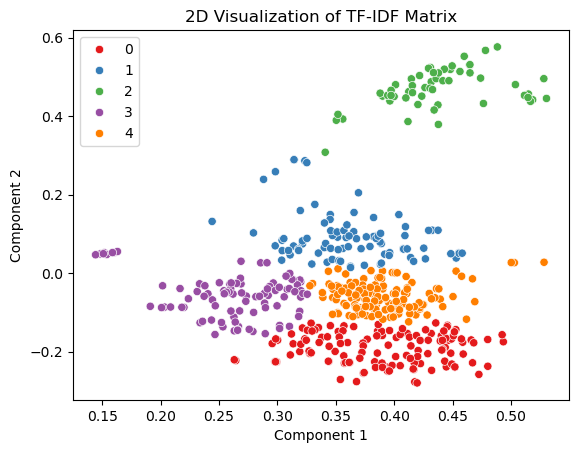

In [77]:
sns.scatterplot(x=reduced_data_2[:, 0], y=reduced_data_2[:, 1], hue=labels2, palette='Set1')
plt.title('2D Visualization of TF-IDF Matrix')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()

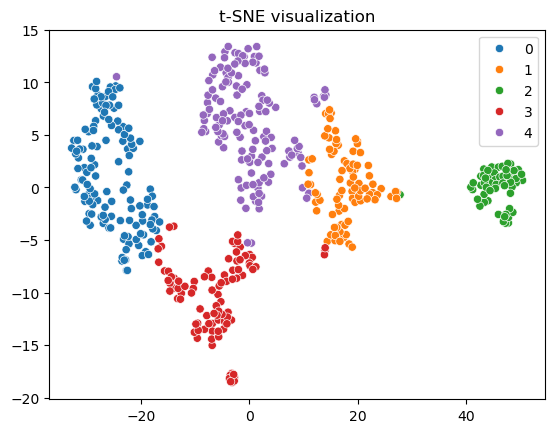

In [79]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(reduced_data_2)

sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels2, palette='tab10')
plt.title("t-SNE visualization")
plt.show()

## Model

### K-means + tf-idf vectorizer

In [68]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans.fit(tfidf_matrix)
labels = kmeans.labels_
df['cluster'] = labels
print(df[['description', 'cluster']].head())

                                         description  cluster
0  Active classic boxers - There's a reason why o...        3
1  Active sport boxer briefs - Skinning up Glory ...        3
2  Active sport briefs - These superbreathable no...        3
3  Alpine guide pants - Skin in, climb ice, switc...        4
4  Alpine wind jkt - On high ridges, steep ice an...        4


In [69]:
df['cluster'].value_counts()

cluster
3    183
4    126
0    108
1     61
2     22
Name: count, dtype: int64

####  Some class imbalance can be seen on some clusters.

In [70]:
labels = KMeans(n_clusters=5, random_state=42).fit_predict(tfidf_matrix)
silhouette_avg = silhouette_score(tfidf_matrix, labels)
davies_bouldin = davies_bouldin_score(tfidf_matrix.toarray(), labels)
calinski_harabasz = calinski_harabasz_score(tfidf_matrix.toarray
(), labels)
print(f"Silhouette Score: {silhouette_avg}")
print(f"Davies-Bouldin Score: {davies_bouldin}")
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

Silhouette Score: 0.04723946095978067
Davies-Bouldin Score: 4.4666617936397675
Calinski-Harabasz Score: 13.27374157467326


### PCA + tf-idf vectorizer

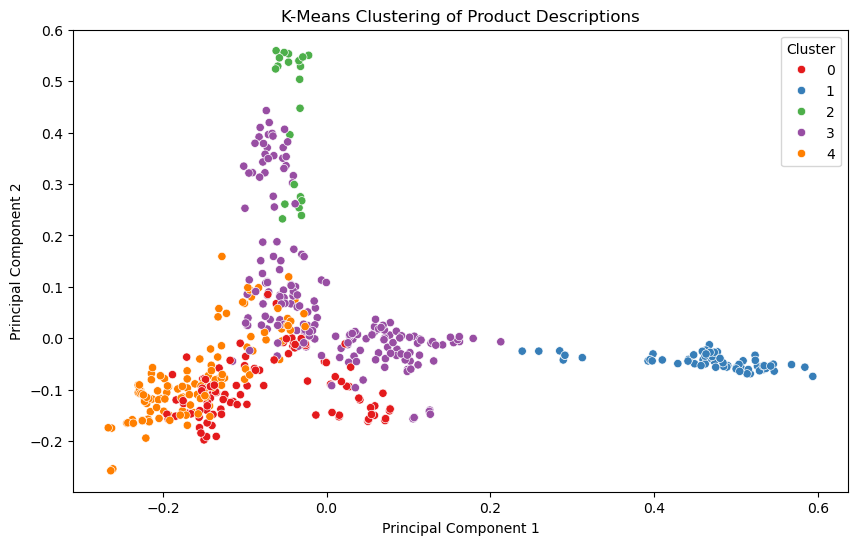

In [71]:
pca = PCA(n_components=2)
reduced_data = pca.fit_transform(tfidf_matrix.toarray())
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=labels, palette='Set1')
plt.title('K-Means Clustering of Product Descriptions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

In [44]:
reduced_data.shape

(500, 2)

In [72]:
dbscan_labels = dbscan(tfidf_matrix, eps=0.5, min_samples=5)[1]
dbscan_silhouette = silhouette_score(tfidf_matrix, dbscan_labels)
dbscan_davies_bouldin = davies_bouldin_score(tfidf_matrix.toarray(), dbscan_labels)
dbscan_calinski_harabasz = calinski_harabasz_score(tfidf_matrix.toarray(), dbscan_labels)
print(f"DBSCAN Silhouette Score: {dbscan_silhouette}")
print(f"DBSCAN Davies-Bouldin Score: {dbscan_davies_bouldin}")
print(f"DBSCAN Calinski-Harabasz Score: {dbscan_calinski_harabasz}")


DBSCAN Silhouette Score: -0.019054628691827166
DBSCAN Davies-Bouldin Score: 1.5402014100673158
DBSCAN Calinski-Harabasz Score: 4.619607044896445
